In [202]:
using LinearAlgebra
using LinearOperators
using SparseArrays
include("main.jl")

compute_BC_corr

In [203]:
n = 64
d = 2
N = n^d

4096

In [204]:
#beta = 4.0 * pi
#gamma = 2.0
#alpha = gamma / beta^2
#
#function u_analytic_fun(t, x)
#    prod(sin.(beta*x)) * exp(- gamma * t)
#end
#

alpha = 0.01
k = 4.74
k2 = k^2
a = 10
beta = 1.0

function X(x)
    prod(sin.(pi*k*x))
end

function u_analytic_fun(x,t)
    X(x) * cos(a*t) * exp(-beta*t)
end

function f_fun(x,t)
    - ( a*sin(a*t) + (beta - alpha*pi^2*k2) ) * cos(a*t) * exp(-beta*t) * X(x)
end

f_fun (generic function with 1 method)

In [205]:
h = 1 / (n+1)

t_max = 0.1
n_iters = 10
tau = t_max / (n_iters-1)
h, tau

(0.015384615384615385, 0.011111111111111112)

In [206]:
# need r <= 1 (implicit) or 1/2 (explicit)
r = alpha * tau / h^2

0.46944444444444444

In [207]:
grid_points_as_1d_vect = get_grid_points_as_1d_vect(n,d);

In [208]:
U_0 = u_analytic_fun.(grid_points_as_1d_vect, 0);

In [209]:
L = get_laplace_sparse_matrix(n,d);

In [210]:
r = alpha * tau / h^2

0.46944444444444444

### Explicit

In [211]:
A_expl = sparse(I, N, N) + r * L;

In [212]:
U_evol_expl = zeros(n_iters, N)
U_evol_expl[1, :] = U_0
for ti in 2:1:n_iters
    t = (ti-1)*tau
    U_evol_expl[ti, :] = A_expl * U_evol_expl[ti-1, :] +
                         tau * f_fun.(grid_points_as_1d_vect, t-tau) +
                         r * compute_BC_corr(u_analytic_fun, t-tau, n, d);
end

In [213]:
U_evol_expl

10×4096 Matrix{Float64}:
 0.0515725  0.10045    0.144079   0.180178   …  0.863456  0.827798  0.748883
 0.0497399  0.0968807  0.138959   0.173776      0.832774  0.798383  0.722272
 0.0473608  0.0922467  0.132312   0.165464      0.799219  0.766213  0.698614
 0.0444979  0.0866706  0.124314   0.155462      0.757407  0.728685  0.663353
 0.0412387  0.0803226  0.115209   0.144075      0.710946  0.682545  0.627587
 0.0376903  0.073411   0.105296   0.131678   …  0.656925  0.636281  0.579302
 0.0339728  0.0661704  0.0949103  0.118691      0.603608  0.576455  0.537785
 0.0302138  0.0588489  0.0844087  0.105558      0.537819  0.532572  0.474239
 0.0265409  0.0516949  0.0741476  0.0927257     0.492998  0.449624  0.44235
 0.0230756  0.0449453  0.0644665  0.0806189     0.39791   0.443653  0.344001

### Implicit

In [214]:
using IterativeSolvers

In [215]:
A_impl = sparse(I, N, N) - r * L;

In [216]:
U_evol_impl = zeros(n_iters, N)
U_evol_impl[1, :] = U_0
for ti in 2:1:n_iters
    t = (ti-1)*tau
    U_evol_impl[ti, :] = cg(
        A_impl,
        U_evol_impl[ti-1, :] +
        tau * f_fun.(grid_points_as_1d_vect, t) +
        r * compute_BC_corr(u_analytic_fun, t-tau, n, d);
        verbose=true
    );
end

  1	5.01e+00
  2	1.04e+00
  3	3.08e-01
  4	1.23e-01
  5	3.99e-02
  6	1.54e-02
  7	5.32e-03
  8	2.00e-03
  9	7.15e-04
 10	2.65e-04
 11	9.62e-05
 12	3.53e-05
 13	1.29e-05
 14	4.72e-06
 15	1.74e-06
 16	6.30e-07
 17	2.32e-07

  1	4.87e+00
  2	1.01e+00
  3	2.98e-01
  4	1.19e-01
  5	3.85e-02
  6	1.49e-02
  7	5.13e-03
  8	1.93e-03
  9	6.89e-04
 10	2.56e-04
 11	9.28e-05
 12	3.41e-05
 13	1.25e-05
 14	4.56e-06
 15	1.67e-06
 16	6.08e-07
 17	2.24e-07

  1	4.69e+00
  2	9.65e-01
  3	2.86e-01
  4	1.14e-01
  5	3.68e-02
  6	1.42e-02
  7	4.91e-03
  8	1.85e-03
  9	6.58e-04
 10	2.45e-04
 11	8.87e-05
 12	3.26e-05
 13	1.19e-05
 14	4.36e-06
 15	1.60e-06
 16	5.81e-07
 17	2.14e-07

  1	4.47e+00
  2	9.18e-01
  3	2.71e-01
  4	1.08e-01
  5	3.48e-02
  6	1.35e-02
  7	4.64e-03
  8	1.75e-03
  9	6.22e-04
 10	2.31e-04
 11	8.38e-05
 12	3.08e-05
 13	1.13e-05
 14	4.12e-06
 15	1.51e-06
 16	5.50e-07
 17	2.02e-07

  1	4.21e+00
  2	8.64e-01
  3	2.54e-01
  4	1.01e-01
  5	3.26e-02
  6	1.26e-02
  7	4.34e-03
  8	1.64e-03
  9	5.82

In [217]:
U_evol_impl

10×4096 Matrix{Float64}:
 0.0515725  0.10045    0.144079   0.180178   …  0.863456  0.827798  0.748883
 0.049219   0.095866   0.137503   0.171956      0.832775  0.799292  0.727124
 0.0464031  0.0903813  0.129637   0.162118      0.798102  0.767501  0.702632
 0.0432072  0.0841566  0.120708   0.150953      0.758755  0.731423  0.673699
 0.0397326  0.077389   0.111001   0.138813      0.714923  0.690985  0.639953
 0.0360936  0.070301   0.100835   0.1261     …  0.667276  0.646651  0.601664
 0.0324112  0.0631287  0.0905474  0.113235      0.616737  0.599177  0.55941
 0.0288073  0.0561092  0.0804791  0.100644      0.56433   0.549445  0.51391
 0.025398   0.0494688  0.0709546  0.0887327     0.511075  0.498354  0.465918
 0.0222882  0.0434118  0.0622668  0.0778681     0.457911  0.44675   0.416168

### Operator approach

In [218]:
function a_op!(v_new, v)
    v_new .= v - r * laplace_operator(v)
end

a_op! (generic function with 1 method)

In [219]:
A_op = LinearOperator(Float64, N, N, true, true, a_op!)

Linear operator
  nrow: 4096
  ncol: 4096
  eltype: Float64
  symmetric: true
  hermitian: true
  nprod:   0
  ntprod:  0
  nctprod: 0



In [220]:
U_evol_op = zeros(n_iters, N)
U_evol_op[1, :] = U_0
for ti in 2:1:n_iters
    t = (ti-1)*tau
    U_evol_op[ti, :] = cg(
        A_op,
        U_evol_op[ti-1, :] +
        tau * f_fun.(grid_points_as_1d_vect, t) +
        r * compute_BC_corr(u_analytic_fun, t-tau, n, d);
        verbose=true
    );
end

  1	5.01e+00
  2	1.04e+00
  3	3.08e-01
  4	1.23e-01
  5	3.99e-02
  6	1.54e-02
  7	5.32e-03
  8	2.00e-03
  9	7.15e-04
 10	2.65e-04
 11	9.62e-05
 12	3.53e-05
 13	1.29e-05
 14	4.72e-06
 15	1.74e-06
 16	6.30e-07
 17	2.32e-07

  1	4.87e+00
  2	1.01e+00
  3	2.98e-01
  4	1.19e-01
  5	3.85e-02
  6	1.49e-02
  7	5.13e-03
  8	1.93e-03
  9	6.89e-04
 10	2.56e-04
 11	9.28e-05
 12	3.41e-05
 13	1.25e-05
 14	4.56e-06
 15	1.67e-06
 16	6.08e-07
 17	2.24e-07

  1	4.69e+00
  2	9.65e-01
  3	2.86e-01
  4	1.14e-01
  5	3.68e-02
  6	1.42e-02
  7	4.91e-03
  8	1.85e-03
  9	6.58e-04
 10	2.45e-04
 11	8.87e-05
 12	3.26e-05
 13	1.19e-05
 14	4.36e-06
 15	1.60e-06
 16	5.81e-07
 17	2.14e-07

  1	4.47e+00
  2	9.18e-01
  3	2.71e-01
  4	1.08e-01
  5	3.48e-02
  6	1.35e-02
  7	4.64e-03
  8	1.75e-03
  9	6.22e-04
 10	2.31e-04
 11	8.38e-05
 12	3.08e-05
 13	1.13e-05
 14	4.12e-06
 15	1.51e-06
 16	5.50e-07
 17	2.02e-07

  1	4.21e+00
  2	8.64e-01
  3	2.54e-01
  4	1.01e-01
  5	3.26e-02
  6	1.26e-02
  7	4.34e-03
  8	1.64e-03
  9	5.82

---

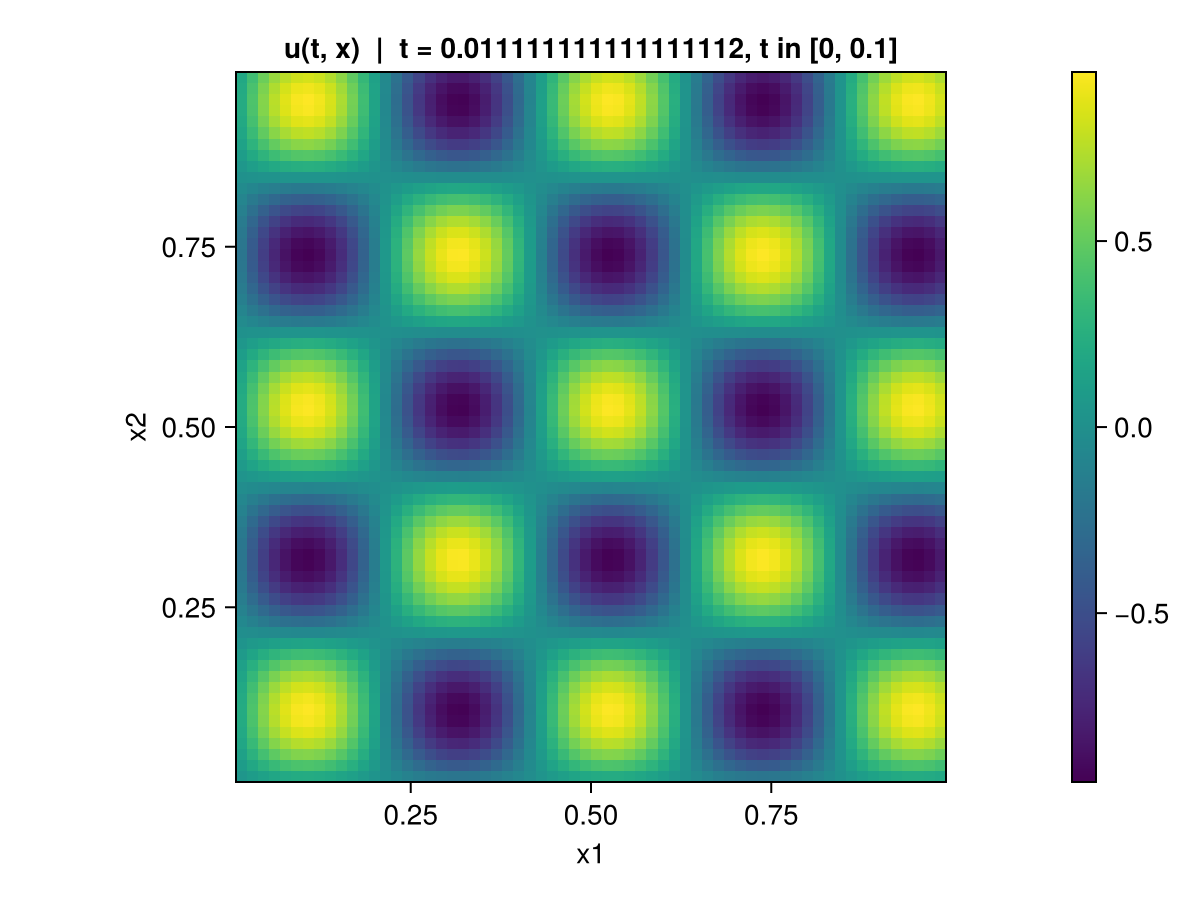

In [221]:
using CairoMakie

ti = 2

t = (ti-1) * tau
U = U_evol_op[ti, :]
#U = u_analytic_fun.(grid_points_as_1d_vect, t);

h = 1/(n+1)
xs = range(h, 1-h; length=n)
U_matrix = reshape(U, ntuple(_ -> n, d)...)

fig, ax, hm = heatmap(xs, xs, U_matrix,
    colormap = :viridis,
    axis = (title = "u(t, x)  |  t = $t, t in [0, $t_max]", xlabel = "x1", ylabel = "x2", aspect = 1)
)
Colorbar(fig[1, 2], hm)
fig

---